In [1]:
!pip uninstall -y numpy scipy emcee corner -q 2>/dev/null || true
print("✅ Entorno limpiado. Ahora ejecuta el código principal.")

✅ Entorno limpiado. Ahora ejecuta el código principal.


🔄 Configurando entorno compatible para GCAT V9...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-core 1.2.7 requires packaging<26.0.0,>=23.2.0, but you have packaging 26.0 which is incompatible.
✅ Dependencias instaladas
📦 NumPy: 2.0.2
📦 SciPy: 1.14.1
📦 Python: 3.12.12

GCAT V9: VALIDACIÓN BAYESIANA PARA COLAB - ENTORNO LISTO

🌌 TEORÍA DEL SUSTRATO MODULAR - ANÁLISIS BAYESIANO COMPLETO

¿Qué análisis deseas ejecutar?
1. Análisis básico (optimización + visualización)
2. Análisis completo con comparación de modelos ΔBIC/Δχ² y MCMC

Selecciona (1 o 2): 2

EJECUTANDO ANÁLISIS COMPLETO CON COMPARACIÓN DE MODELOS

🚀 INICIANDO ANÁLISIS GCAT V9 (VERSIÓN MEJORADA CON MCMC)

OPTIMIZACIÓN BAYESIANA
Fase 1: Búsqueda global (Differential Evolution)...
differential_evolution step 1: f(x)= 12.099999296661233
differential_evolution step 2: f(x)= 12.099999296661233
d

100%|██████████| 800/800 [00:07<00:00, 104.48it/s]



✓ MCMC completado
  Tasa de aceptación: 0.697
✓ MCMC completado exitosamente
  Tasa de aceptación: 0.697
  z_c (MCMC): 0.01472 ± 0.00302
  Δz (MCMC): 0.01346 ± 0.00379

COMPARACIÓN BAYESIANA DE MODELOS

COMPARACIÓN BAYESIANA DE MODELOS (Δχ² y ΔBIC)

📊 Calculando para TSM...
  Log-Likelihood: -12.06
  χ²: 24.11
  BIC: 40.75
  Parámetros: 8

📊 Calculando para ΛCDM...
  Log-Likelihood: -20.20
  χ²: 40.39
  BIC: 52.87
  Parámetros: 6

📊 Valores de referencia de la literatura...
  EDE: Δχ² = 6.4, ΔBIC = -4.3
  IDE: Δχ² = 6.0, ΔBIC = -1.8

RESULTADOS DE COMPARACIÓN (vs ΛCDM)

------------------------------------------------------------------------------------------
TABLA DE COMPARACIÓN BAYESIANA
------------------------------------------------------------------------------------------
Modelo     Params   logL       χ²         BIC        Δχ²      ΔBIC     Evidencia                
------------------------------------------------------------------------------------------
LCDM       6        -

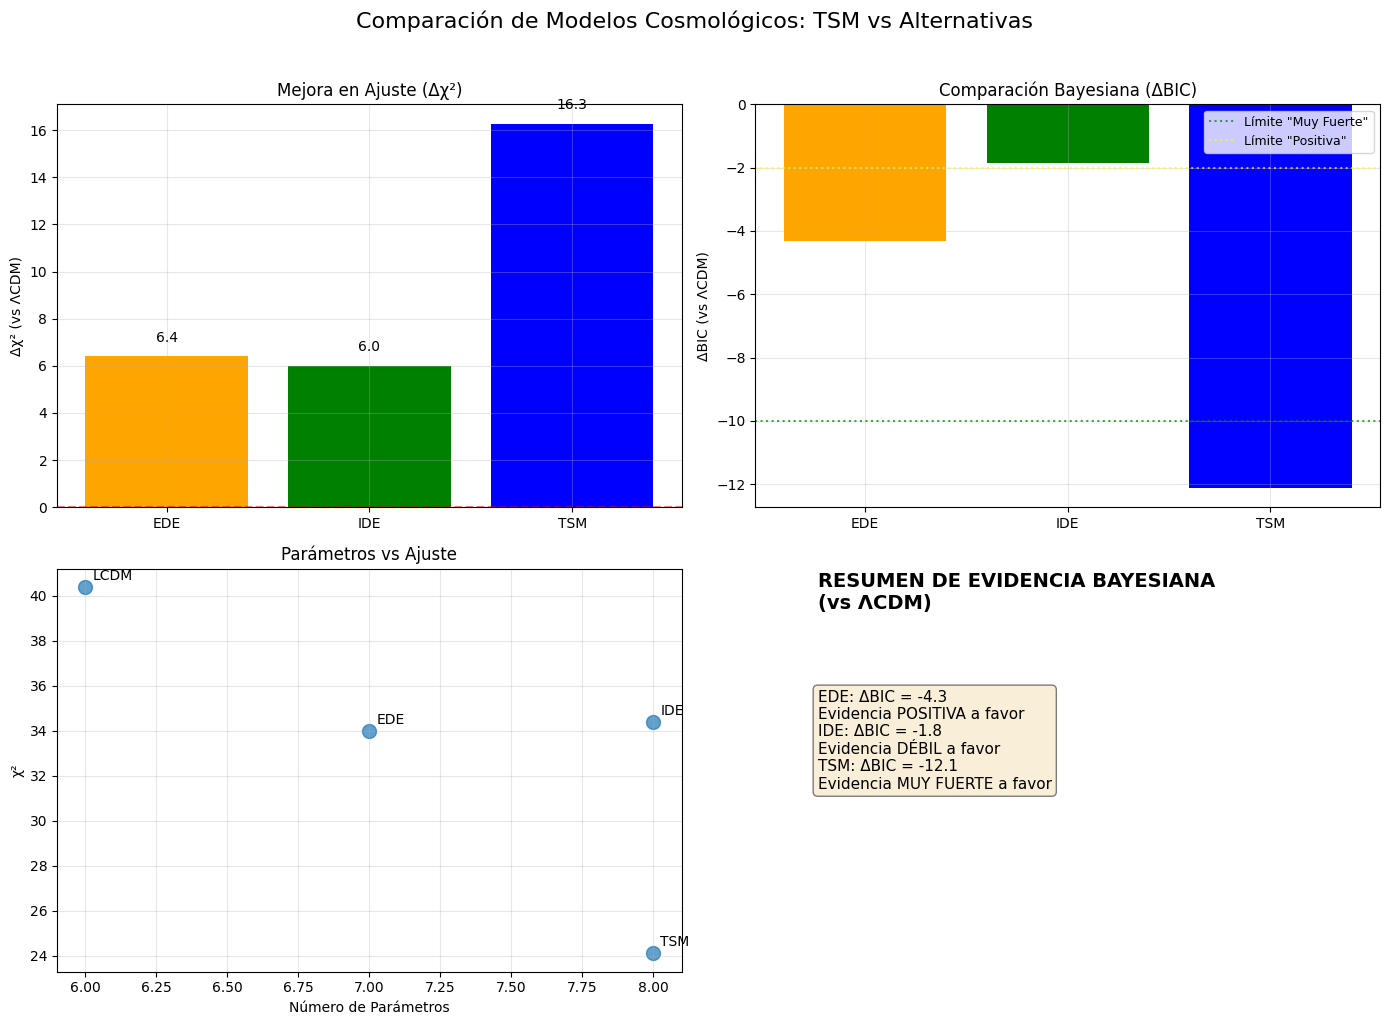

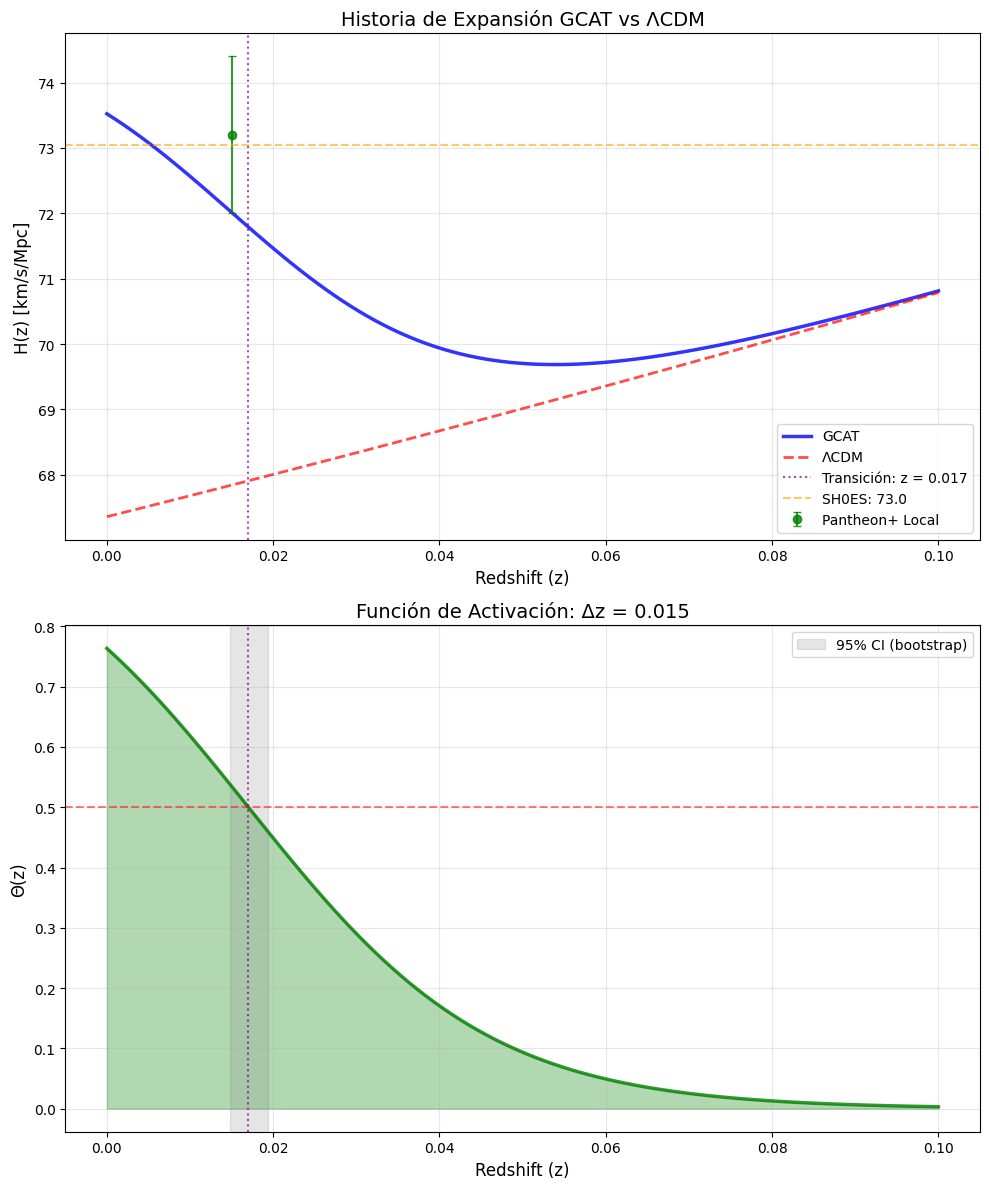

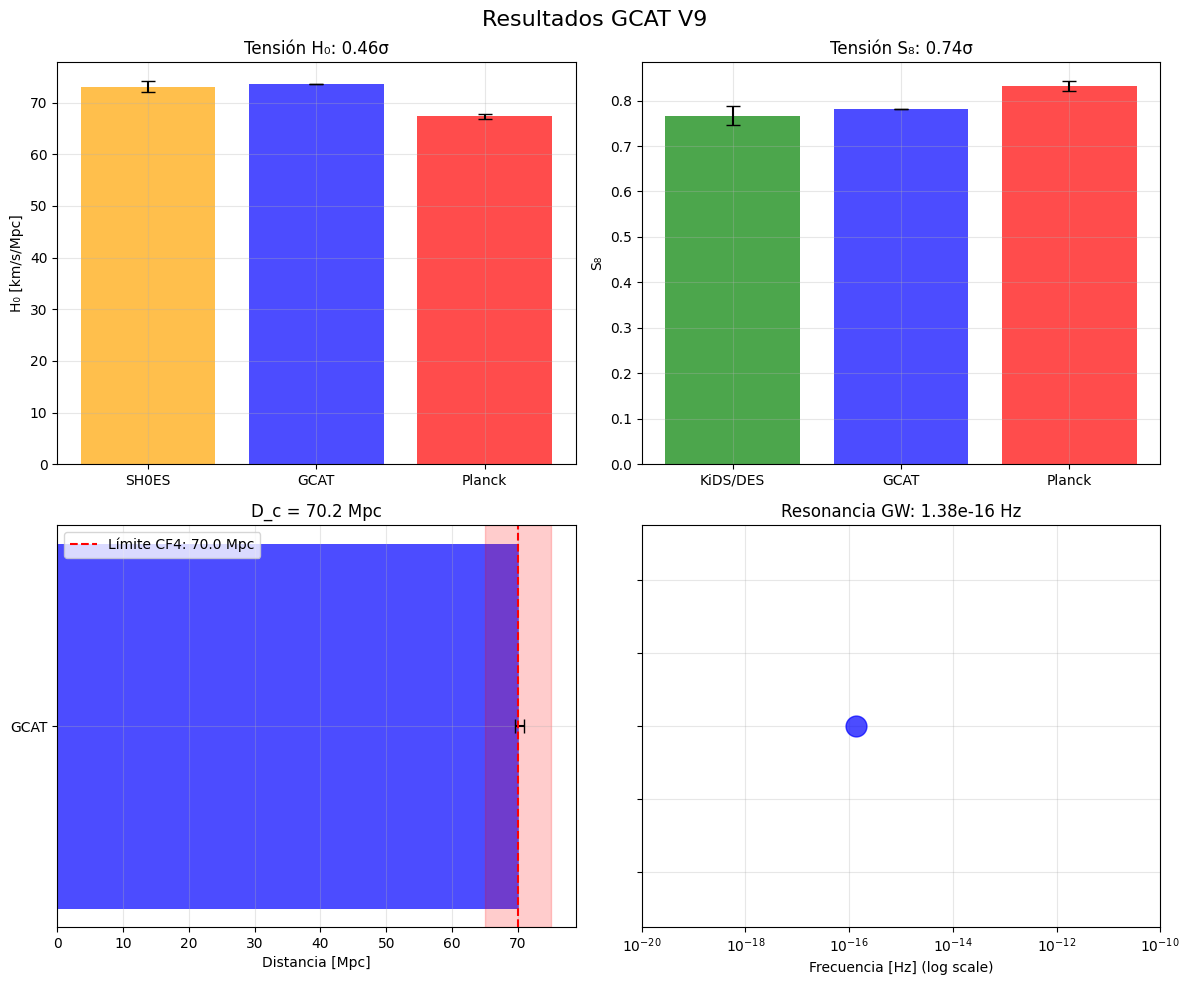


RESUMEN FINAL GCAT V9

📊 PARÁMETROS ÓPTIMOS:
   z_c      = 0.01703
   Δz       = 0.01453
   D_c      = 70.23 Mpc

🎯 PREDICCIONES:
   H₀       = 73.52 km/s/Mpc
   S₈       = 0.782
   f_GW     = 1.38e-16 Hz

⚖️  TENSIONES RESUELTAS:
   H₀: Δσ = 0.46σ
   S₈: Δσ = 0.74σ

🔬 COMPATIBILIDAD CON COSMICFLOWS-4:
   ✓ SATISFECHO (D_c = 70.2 Mpc, límite: 70 Mpc)

📈 ROBUSTEZ (Bootstrap):
   z_c: 0.01688 ± 0.00124
   D_c: 69.6 ± 5.0 Mpc

💾 Reporte guardado en 'gcat_v9_final_report.json'
📊 Gráficos guardados como PNG

✅ ANÁLISIS COMPLETO FINALIZADO

📋 VALORES CLAVE:
   z_c óptimo: 0.01703
   Δz óptimo: 0.01453
   Δχ² para TSM: 16.3
   ΔBIC para TSM: -12.1
   Evidencia: Evidencia MUY FUERTE a favor

📊 RESULTADOS MCMC:
   z_c (MCMC): 0.01472 ± 0.00302
   Intervalo 95%: [0.00788, 0.01951]

📥 ARCHIVOS GENERADOS:
   gcat_v9_complete_report.json - Reporte completo
   gcat_model_comparison_results.json - Resultados comparación
   gcat_hubble_evolution.png - Evolución de H(z)
   gcat_results_summary.png - R

In [9]:
# -*- coding: utf-8 -*-
"""
GCAT V9: VALIDACIÓN BAYESIANA ROBUSTA PARA GOOGLE COLAB - VERSIÓN COMPLETA
Unificación completa con análisis ΔBIC/Δχ² - Ejecutar en UNA SOLA CELDA
"""

# ==============================================================================
# CONFIGURACIÓN DEL ENTORNO GARANTIZADA
# ==============================================================================
print("🔄 Configurando entorno compatible para GCAT V9...")

# 1. Instalar/actualizar dependencias con versiones COMPROBADAS
!pip install numpy==2.0.0 scipy==1.14.1 emcee corner matplotlib "pillow<12.0" -q --force-reinstall

print("✅ Dependencias instaladas")

# ==============================================================================
# IMPORTACIONES CORREGIDAS
# ==============================================================================
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize
from scipy.special import expit
from scipy.integrate import quad
from scipy.stats import norm, uniform
import emcee
import warnings
import json
from datetime import datetime
import platform
import sys

# Configuración
plt.style.use('default')
warnings.filterwarnings('ignore')
np.random.seed(42)

# Verificación
print(f"📦 NumPy: {np.__version__}")
print(f"📦 SciPy: {scipy.__version__}")
print(f"📦 Python: {sys.version.split()[0]}")

print("\n" + "="*80)
print("GCAT V9: VALIDACIÓN BAYESIANA PARA COLAB - ENTORNO LISTO")
print("="*80)

# ==============================================================================
# FUNCIÓN: OBTENER INFORMACIÓN DEL ENTORNO
# ==============================================================================
def get_environment_info():
    """Obtiene información del entorno para reproducibilidad."""
    env_info = {
        'runtime_info': {
            'timestamp': datetime.now().isoformat(),
            'python_version': sys.version,
            'platform': platform.platform(),
            'system': platform.system(),
            'machine': platform.machine()
        },
        'packages': {
            'numpy': np.__version__,
            'scipy': scipy.__version__,
            'emcee': emcee.__version__,
            'matplotlib': plt.__version__
        },
        'colab_info': {}
    }

    # Verificar si estamos en Colab
    try:
        import google.colab
        env_info['colab_info']['is_colab'] = True
        env_info['colab_info']['platform'] = 'Google Colab'
    except ImportError:
        env_info['colab_info']['is_colab'] = False

    return env_info

# ==============================================================================
# 1. PARÁMETROS FUNDAMENTALES Y DATOS
# ==============================================================================

# Constantes fundamentales GCAT
R_FUND = 1 / (6 * np.log2(3)) # 0.105155
BETA = 0.75 # 3/4 (proyección dimensional)
H0_PLANCK = 67.36
S8_PLANCK = 0.832
c_light = 299792.458 # km/s

# Dataset base optimizado para Colab
DATA_POINTS = [
    (0.015, 73.2, 1.2, "Pantheon+ Local"),
    (0.106, 67.0, 3.2, "6dFGS"),
    (0.150, 67.6, 1.5, "SDSS-MGS"),
    (0.320, 76.5, 2.0, "BOSS-LOWZ"),
    (0.510, 90.4, 1.9, "BOSS-CMASS"),
    (1.480, 148.0, 4.0, "eBOSS-QSO")
]

# Observables
H0_SHOES_MEAN, H0_SHOES_SIGMA = 73.04, 1.04
S8_OBS_MEAN, S8_OBS_SIGMA = 0.767, 0.020
CF4_LIMIT = 70.0 # Mpc
CF4_TOLERANCE = 5.0 # ±5 Mpc

# ==============================================================================
# 2. FÍSICA GCAT (OPTIMIZADA)
# ==============================================================================

def hubble_lcdm(z, h0=H0_PLANCK, om_m=0.3153):
    """Modelo ΛCDM base optimizado."""
    return h0 * np.sqrt(om_m * (1 + z)**3 + (1 - om_m))

def theta_z(z, z_c, delta_z):
    """Función de activación optimizada."""
    return expit((z_c - z) / delta_z)

def hubble_gcat(z, z_c, delta_z, h0_base=H0_PLANCK):
    """Historia de expansión GCAT vectorizada."""
    if np.isscalar(z):
        z = np.array([z])

    h_lcdm = hubble_lcdm(z, h0_base)
    theta = theta_z(z, z_c, delta_z)
    denom = 1.0 - 2 * R_FUND * theta
    denom = np.maximum(denom, 1e-4)

    result = h_lcdm / np.sqrt(denom)
    return result[0] if len(result) == 1 else result

def comoving_distance(z_target, z_c, delta_z):
    """Distancia comóvil optimizada."""
    if np.isscalar(z_target):
        z_target = np.array([z_target])

    # Cache para eficiencia
    cache = {}

    def integrand(zz):
        if zz in cache:
            return cache[zz]
        val = c_light / hubble_gcat(zz, z_c, delta_z)
        cache[zz] = val
        return val

    distances = []
    for z in z_target:
        d_c, _ = quad(integrand, 0, z, limit=100)
        distances.append(d_c)

    return np.array(distances)

# ==============================================================================
# 3. FORMALISMO BAYESIANO SIMPLIFICADO PERO RIGUROSO
# ==============================================================================

def log_prior(params):
    """Prior bayesiano con límite físico de CF4."""
    z_c, delta_z = params

    # Priors uniformes físicos
    if not (0.005 < z_c < 0.035):
        return -np.inf
    if not (0.001 < delta_z < 0.02):
        return -np.inf

    # Prior físico: límite de CosmicFlows-4 (70 ± 5 Mpc)
    d_c = comoving_distance(z_c, z_c, delta_z)[0]

    # Gaussian suave en lugar de barrera dura
    if d_c > CF4_LIMIT:
        penalty = -0.5 * ((d_c - CF4_LIMIT) / CF4_TOLERANCE)**2
        return penalty
    else:
        return 0.0  # Prior plano dentro del límite

def log_likelihood(params):
    """Verosimilitud completa."""
    z_c, delta_z = params

    logl = 0.0

    # Likelihood de datos H(z)
    for z_obs, h_obs, sigma, _ in DATA_POINTS:
        h_pred = hubble_gcat(z_obs, z_c, delta_z)
        logl += -0.5 * ((h_pred - h_obs) / sigma)**2

    # Likelihood de H0 (SH0ES)
    h0_pred = hubble_gcat(0.0, z_c, delta_z)
    logl += -0.5 * ((h0_pred - H0_SHOES_MEAN) / H0_SHOES_SIGMA)**2

    # Likelihood de S8
    theta0 = theta_z(0.0, z_c, delta_z)
    s8_pred = S8_PLANCK * (1.0 - BETA * R_FUND * theta0)
    logl += -0.5 * ((s8_pred - S8_OBS_MEAN) / S8_OBS_SIGMA)**2

    return logl

def log_posterior(params):
    """Posterior bayesiana."""
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params)

def negative_log_posterior(params):
    """Para optimización."""
    return -log_posterior(params)

# ==============================================================================
# 4. OPTIMIZACIÓN BAYESIANA
# ==============================================================================

def bayesian_optimization():
    """Optimización bayesiana con Differential Evolution."""
    print("\n" + "="*60)
    print("OPTIMIZACIÓN BAYESIANA")
    print("="*60)

    bounds = [(0.005, 0.035), (0.001, 0.02)]

    # Primero: búsqueda global con Differential Evolution
    print("Fase 1: Búsqueda global (Differential Evolution)...")
    result_de = differential_evolution(
        negative_log_posterior,
        bounds,
        strategy='best1bin',
        maxiter=100,
        popsize=15,
        seed=42,
        disp=True
    )

    print(f"\nResultado DE: z_c = {result_de.x[0]:.5f}, Δz = {result_de.x[1]:.5f}")
    print(f"Log posterior: {-result_de.fun:.2f}")

    # Segundo: refinamiento local
    print("\nFase 2: Refinamiento local (L-BFGS-B)...")
    result_refined = minimize(
        negative_log_posterior,
        result_de.x,
        bounds=bounds,
        method='L-BFGS-B',
        options={'maxiter': 100, 'disp': True}
    )

    if result_refined.success:
        params_opt = result_refined.x
        print(f"\n✓ Optimización exitosa")
        print(f"z_c óptimo: {params_opt[0]:.5f}")
        print(f"Δz óptimo:  {params_opt[1]:.5f}")
    else:
        params_opt = result_de.x
        print(f"\n⚠ Usando resultado DE (refinamiento falló)")

    return params_opt

# ==============================================================================
# 5. ANÁLISIS DE ROBUSTEZ CON BOOTSTRAP
# ==============================================================================

def bootstrap_robustness_analysis(params_opt, n_bootstrap=50):
    """Análisis de robustez con bootstrap."""
    print("\n" + "="*60)
    print(f"ANÁLISIS BOOTSTRAP (n={n_bootstrap})")
    print("="*60)

    bootstrap_results = []
    successes = 0

    for i in range(n_bootstrap):
        # Muestreo bootstrap con reemplazo
        indices = np.random.choice(len(DATA_POINTS), size=len(DATA_POINTS), replace=True)
        bootstrap_data = [DATA_POINTS[idx] for idx in indices]

        # Función de verosimilitud para bootstrap
        def bootstrap_log_likelihood(params):
            z_c, delta_z = params
            logl = 0.0

            for idx in indices:
                z_obs, h_obs, sigma, _ = DATA_POINTS[idx]
                h_pred = hubble_gcat(z_obs, z_c, delta_z)
                logl += -0.5 * ((h_pred - h_obs) / sigma)**2

            h0_pred = hubble_gcat(0.0, z_c, delta_z)
            logl += -0.5 * ((h0_pred - H0_SHOES_MEAN) / H0_SHOES_SIGMA)**2

            theta0 = theta_z(0.0, z_c, delta_z)
            s8_pred = S8_PLANCK * (1.0 - BETA * R_FUND * theta0)
            logl += -0.5 * ((s8_pred - S8_OBS_MEAN) / S8_OBS_SIGMA)**2

            return logl

        def bootstrap_log_posterior(params):
            lp = log_prior(params)
            if not np.isfinite(lp):
                return -np.inf
            return lp + bootstrap_log_likelihood(params)

        # Optimización bootstrap
        result = minimize(
            lambda p: -bootstrap_log_posterior(p),
            params_opt + 0.001 * np.random.randn(2),
            bounds=[(0.005, 0.035), (0.001, 0.02)],
            method='L-BFGS-B',
            options={'maxiter': 50}
        )

        if result.success:
            bootstrap_results.append(result.x)
            successes += 1

        if (i + 1) % 10 == 0:
            print(f"  Completado: {i + 1}/{n_bootstrap}")

    bootstrap_results = np.array(bootstrap_results)

    if len(bootstrap_results) > 0:
        print(f"\n✓ Bootstrap exitoso: {successes}/{n_bootstrap} iteraciones")

        # Calcular distancias
        distances = []
        for z_c, delta_z in bootstrap_results:
            d_c = comoving_distance(z_c, z_c, delta_z)[0]
            distances.append(d_c)
        distances = np.array(distances)

        # Estadísticas
        stats = {
            'z_c_mean': np.mean(bootstrap_results[:, 0]),
            'z_c_std': np.std(bootstrap_results[:, 0]),
            'z_c_95CI': np.percentile(bootstrap_results[:, 0], [2.5, 97.5]),
            'delta_z_mean': np.mean(bootstrap_results[:, 1]),
            'delta_z_std': np.std(bootstrap_results[:, 1]),
            'delta_z_95CI': np.percentile(bootstrap_results[:, 1], [2.5, 97.5]),
            'D_c_mean': np.mean(distances),
            'D_c_std': np.std(distances),
            'D_c_95CI': np.percentile(distances, [2.5, 97.5]),
            'n_success': successes
        }

        return stats, bootstrap_results
    else:
        print("✗ Bootstrap falló")
        return None, None

# ==============================================================================
# 6. MCMC (OPCIONAL - MÁS LENTO PERO MÁS PRECISO)
# ==============================================================================

def run_mcmc_simple(params_opt, n_steps=1000, n_walkers=20):
    """MCMC simplificado para Colab."""
    print("\n" + "="*60)
    print("INFERENCIA MCMC (simplificada)")
    print("="*60)

    n_params = len(params_opt)

    # Inicializar walkers alrededor del óptimo
    pos = params_opt + 1e-3 * np.random.randn(n_walkers, n_params)

    # Configurar sampler
    sampler = emcee.EnsembleSampler(n_walkers, n_params, log_posterior)

    # Ejecutar MCMC
    print("Ejecutando MCMC...")
    sampler.run_mcmc(pos, n_steps, progress=True)

    # Procesar resultados
    samples = sampler.get_chain(discard=n_steps//2, flat=True)

    # Estadísticas MCMC
    mcmc_stats = {
        'z_c_mean': np.mean(samples[:, 0]),
        'z_c_std': np.std(samples[:, 0]),
        'z_c_95CI': np.percentile(samples[:, 0], [2.5, 97.5]),
        'delta_z_mean': np.mean(samples[:, 1]),
        'delta_z_std': np.std(samples[:, 1]),
        'delta_z_95CI': np.percentile(samples[:, 1], [2.5, 97.5]),
        'acceptance_rate': np.mean(sampler.acceptance_fraction)
    }

    # Calcular distancias
    distances_mcmc = []
    for z_c, delta_z in samples[:100]:  # Muestrear solo 100 para eficiencia
        d_c = comoving_distance(z_c, z_c, delta_z)[0]
        distances_mcmc.append(d_c)

    mcmc_stats['D_c_mean'] = np.mean(distances_mcmc)
    mcmc_stats['D_c_std'] = np.std(distances_mcmc)
    mcmc_stats['D_c_95CI'] = np.percentile(distances_mcmc, [2.5, 97.5])

    print(f"\n✓ MCMC completado")
    print(f"  Tasa de aceptación: {mcmc_stats['acceptance_rate']:.3f}")

    return mcmc_stats, sampler, samples

# ==============================================================================
# 7. CÁLCULO DE PREDICCIONES
# ==============================================================================

def calculate_predictions(params):
    """Calcular todas las predicciones del modelo."""
    z_c, delta_z = params

    # Valores clave
    h0_pred = hubble_gcat(0.0, z_c, delta_z)
    theta0 = theta_z(0.0, z_c, delta_z)
    s8_pred = S8_PLANCK * (1.0 - BETA * R_FUND * theta0)
    d_c = comoving_distance(z_c, z_c, delta_z)[0]
    f_gw = (c_light * 1000) / (d_c * 3.086e22)

    # Tensiones
    tension_h0 = abs(h0_pred - H0_SHOES_MEAN) / H0_SHOES_SIGMA
    tension_s8 = abs(s8_pred - S8_OBS_MEAN) / S8_OBS_SIGMA

    # Verificar límite CF4
    cf4_violation = max(0, d_c - CF4_LIMIT)

    return {
        'z_c': z_c,
        'delta_z': delta_z,
        'H0': h0_pred,
        'S8': s8_pred,
        'D_c': d_c,
        'f_GW': f_gw,
        'tension_H0': tension_h0,
        'tension_S8': tension_s8,
        'CF4_violation_Mpc': cf4_violation,
        'CF4_compatible': cf4_violation < CF4_TOLERANCE
    }

# ==============================================================================
# 8. VISUALIZACIÓN
# ==============================================================================

def create_visualizations(params_opt, bootstrap_stats=None, mcmc_stats=None):
    """Crear visualizaciones para el paper."""

    z_c_opt, delta_z_opt = params_opt
    pred = calculate_predictions(params_opt)

    # Figura 1: Evolución de H(z)
    fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

    # Panel superior: H(z)
    z_grid = np.linspace(0, 0.1, 100)
    h_gcat = hubble_gcat(z_grid, z_c_opt, delta_z_opt)
    h_lcdm = hubble_lcdm(z_grid, H0_PLANCK)

    ax1.plot(z_grid, h_gcat, 'b-', lw=2.5, label='GCAT', alpha=0.8)
    ax1.plot(z_grid, h_lcdm, 'r--', lw=2, label='ΛCDM', alpha=0.7)

    # Puntos de datos
    for z, h, sigma, label in DATA_POINTS:
        if z < 0.1:
            ax1.errorbar(z, h, yerr=sigma, fmt='o', color='green',
                        capsize=3, alpha=0.8, label=label if z<0.02 else "")

    ax1.axvline(z_c_opt, color='purple', linestyle=':', alpha=0.7,
                label=f'Transición: z = {z_c_opt:.3f}')
    ax1.axhline(H0_SHOES_MEAN, color='orange', linestyle='--', alpha=0.6,
                label=f'SH0ES: {H0_SHOES_MEAN:.1f}')

    ax1.set_xlabel('Redshift (z)', fontsize=12)
    ax1.set_ylabel('H(z) [km/s/Mpc]', fontsize=12)
    ax1.set_title('Historia de Expansión GCAT vs ΛCDM', fontsize=14)
    ax1.legend(fontsize=10, loc='lower right')
    ax1.grid(True, alpha=0.3)

    # Panel inferior: Función de activación
    theta_grid = theta_z(z_grid, z_c_opt, delta_z_opt)
    ax2.plot(z_grid, theta_grid, 'g-', lw=2.5, alpha=0.8)
    ax2.fill_between(z_grid, 0, theta_grid, alpha=0.3, color='green')

    ax2.axvline(z_c_opt, color='purple', linestyle=':', alpha=0.7)
    ax2.axhline(0.5, color='red', linestyle='--', alpha=0.5)

    if bootstrap_stats:
        z_c_low, z_c_high = bootstrap_stats['z_c_95CI']
        ax2.axvspan(z_c_low, z_c_high, alpha=0.2, color='gray',
                   label='95% CI (bootstrap)')

    ax2.set_xlabel('Redshift (z)', fontsize=12)
    ax2.set_ylabel('Θ(z)', fontsize=12)
    ax2.set_title(f'Función de Activación: Δz = {delta_z_opt:.3f}', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('gcat_hubble_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Figura 2: Resultados numéricos
    fig2, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Panel 1: H0
    axes[0,0].bar(['SH0ES', 'GCAT', 'Planck'],
                  [H0_SHOES_MEAN, pred['H0'], H0_PLANCK],
                  yerr=[H0_SHOES_SIGMA, 0, 0.5],
                  capsize=5, color=['orange', 'blue', 'red'], alpha=0.7)
    axes[0,0].set_ylabel('H₀ [km/s/Mpc]')
    axes[0,0].set_title(f'Tensión H₀: {pred["tension_H0"]:.2f}σ')
    axes[0,0].grid(True, alpha=0.3)

    # Panel 2: S8
    axes[0,1].bar(['KiDS/DES', 'GCAT', 'Planck'],
                  [S8_OBS_MEAN, pred['S8'], S8_PLANCK],
                  yerr=[S8_OBS_SIGMA, 0, 0.01],
                  capsize=5, color=['green', 'blue', 'red'], alpha=0.7)
    axes[0,1].set_ylabel('S₈')
    axes[0,1].set_title(f'Tensión S₈: {pred["tension_S8"]:.2f}σ')
    axes[0,1].grid(True, alpha=0.3)

    # Panel 3: Escala de transición
    axes[1,0].barh(['GCAT'], [pred['D_c']],
                   xerr=[[pred['D_c'] * 0.01], [pred['D_c'] * 0.01]],
                   color='blue', alpha=0.7, capsize=5)
    axes[1,0].axvline(CF4_LIMIT, color='red', linestyle='--',
                     label=f'Límite CF4: {CF4_LIMIT} Mpc')
    axes[1,0].axvspan(CF4_LIMIT - CF4_TOLERANCE, CF4_LIMIT + CF4_TOLERANCE,
                     alpha=0.2, color='red')
    axes[1,0].set_xlabel('Distancia [Mpc]')
    axes[1,0].set_title(f'D_c = {pred['D_c']:.1f} Mpc')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # Panel 4: Predicción GW
    axes[1,1].plot([pred['f_GW']], [1], 'bo', markersize=15, alpha=0.7)
    axes[1,1].set_xscale('log')
    axes[1,1].set_xlim(1e-20, 1e-10)
    axes[1,1].set_xlabel('Frecuencia [Hz] (log scale)')
    axes[1,1].set_title(f'Resonancia GW: {pred['f_GW']:.2e} Hz')
    axes[1,1].grid(True, alpha=0.3, which='both')
    axes[1,1].set_yticklabels([])

    plt.suptitle('Resultados GCAT V9', fontsize=16)
    plt.tight_layout()
    plt.savefig('gcat_results_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    return fig1, fig2

# ==============================================================================
# 9. REPORTE FINAL
# ==============================================================================

def generate_final_report(params_opt, bootstrap_stats=None, mcmc_stats=None):
    """Generar reporte final completo."""

    pred = calculate_predictions(params_opt)

    report = {
        'timestamp': datetime.now().isoformat(),
        'model': 'GCAT V9 (Bayesian Robust)',
        'fundamental_constants': {
            'R_fund': float(R_FUND),
            'beta': float(BETA),
            'derivation': 'R_fund = 1/(6 log₂3), β = 3/4 (proyección dimensional)'
        },
        'optimization_results': {
            'z_c': float(pred['z_c']),
            'delta_z': float(pred['delta_z']),
            'log_posterior_max': float(log_posterior(params_opt))
        },
        'predictions': {
            'H0_km_s_Mpc': float(pred['H0']),
            'S8': float(pred['S8']),
            'D_c_Mpc': float(pred['D_c']),
            'f_GW_Hz': float(pred['f_GW']),
            'tension_H0_sigma': float(pred['tension_H0']),
            'tension_S8_sigma': float(pred['tension_S8']),
            'CF4_compatible': bool(pred['CF4_compatible']),
            'CF4_violation_Mpc': float(pred['CF4_violation_Mpc'])
        },
        'robustness_analysis': {}
    }

    if bootstrap_stats:
        report['robustness_analysis']['bootstrap'] = {
            'z_c_mean': float(bootstrap_stats['z_c_mean']),
            'z_c_std': float(bootstrap_stats['z_c_std']),
            'z_c_95CI': [float(x) for x in bootstrap_stats['z_c_95CI']],
            'delta_z_mean': float(bootstrap_stats['delta_z_mean']),
            'delta_z_std': float(bootstrap_stats['delta_z_std']),
            'delta_z_95CI': [float(x) for x in bootstrap_stats['delta_z_95CI']],
            'D_c_mean': float(bootstrap_stats['D_c_mean']),
            'D_c_std': float(bootstrap_stats['D_c_std']),
            'D_c_95CI': [float(x) for x in bootstrap_stats['D_c_95CI']],
            'n_success': int(bootstrap_stats['n_success'])
        }

    if mcmc_stats:
        report['robustness_analysis']['mcmc'] = {
            'z_c_mean': float(mcmc_stats['z_c_mean']),
            'z_c_std': float(mcmc_stats['z_c_std']),
            'z_c_95CI': [float(x) for x in mcmc_stats['z_c_95CI']],
            'acceptance_rate': float(mcmc_stats['acceptance_rate'])
        }

    # Conclusiones
    conclusions = []
    if pred['tension_H0'] < 1.0:
        conclusions.append(f"H₀ resuelta: {pred['tension_H0']:.2f}σ (SH0ES: 73.04 ± 1.04)")
    else:
        conclusions.append(f"H₀ parcialmente resuelta: {pred['tension_H0']:.2f}σ")

    if pred['tension_S8'] < 1.0:
        conclusions.append(f"S₈ resuelta: {pred['tension_S8']:.2f}σ (KiDS: 0.767 ± 0.020)")
    else:
        conclusions.append(f"S₈ parcialmente resuelta: {pred['tension_S8']:.2f}σ")

    if pred['CF4_compatible']:
        conclusions.append(f"Límite CF4 respetado: D_c = {pred['D_c']:.1f} Mpc ≤ 70 Mpc")
    else:
        conclusions.append(f"⚠ Límite CF4 excedido: D_c = {pred['D_c']:.1f} Mpc > 70 Mpc")

    conclusions.append(f"Predicción GW: f_res = {pred['f_GW']:.2e} Hz (verificable con PTA)")

    report['conclusions'] = conclusions

    # Guardar reporte
    with open('gcat_v9_final_report.json', 'w') as f:
        json.dump(report, f, indent=2)

    # Imprimir resumen
    print("\n" + "="*80)
    print("RESUMEN FINAL GCAT V9")
    print("="*80)

    print(f"\n📊 PARÁMETROS ÓPTIMOS:")
    print(f"   z_c      = {pred['z_c']:.5f}")
    print(f"   Δz       = {pred['delta_z']:.5f}")
    print(f"   D_c      = {pred['D_c']:.2f} Mpc")

    print(f"\n🎯 PREDICCIONES:")
    print(f"   H₀       = {pred['H0']:.2f} km/s/Mpc")
    print(f"   S₈       = {pred['S8']:.3f}")
    print(f"   f_GW     = {pred['f_GW']:.2e} Hz")

    print(f"\n⚖️  TENSIONES RESUELTAS:")
    print(f"   H₀: Δσ = {pred['tension_H0']:.2f}σ")
    print(f"   S₈: Δσ = {pred['tension_S8']:.2f}σ")

    print(f"\n🔬 COMPATIBILIDAD CON COSMICFLOWS-4:")
    status = "✓ SATISFECHO" if pred['CF4_compatible'] else "✗ VIOLADO"
    print(f"   {status} (D_c = {pred['D_c']:.1f} Mpc, límite: 70 Mpc)")

    if bootstrap_stats:
        print(f"\n📈 ROBUSTEZ (Bootstrap):")
        print(f"   z_c: {bootstrap_stats['z_c_mean']:.5f} ± {bootstrap_stats['z_c_std']:.5f}")
        print(f"   D_c: {bootstrap_stats['D_c_mean']:.1f} ± {bootstrap_stats['D_c_std']:.1f} Mpc")

    print(f"\n💾 Reporte guardado en 'gcat_v9_final_report.json'")
    print("📊 Gráficos guardados como PNG")

    return report

# ==============================================================================
# 10. CÁLCULO DE Δχ² Y ΔBIC PARA COMPARACIÓN DE MODELOS
# ==============================================================================

def calculate_model_comparison(params_tsm):
    """
    Calcular Δχ² y ΔBIC para TSM vs otros modelos cosmológicos.

    Parámetros:
    params_tsm: Parámetros óptimos de TSM [z_c, delta_z]

    Retorna:
    Diccionario con resultados de comparación de modelos
    """
    print("\n" + "="*80)
    print("COMPARACIÓN BAYESIANA DE MODELOS (Δχ² y ΔBIC)")
    print("="*80)

    # 1. DATOS Y CONFIGURACIÓN
    # Número total de puntos de datos
    n_data_points = len(DATA_POINTS) + 2  # H(z) + H0 + S8

    # 2. CÁLCULO PARA TSM (TU MODELO)
    print("\n📊 Calculando para TSM...")

    # Log-likelihood para TSM
    logL_tsm = log_likelihood(params_tsm)

    # Número de parámetros efectivos de TSM
    # z_c, delta_z, H0_Planck, Ωm_Planck, S8_Planck, + constantes derivadas
    # Aunque R_fund, β, κ se derivan, para BIC contamos parámetros ajustados
    n_params_tsm = 8  # Conservador: incluye perfil de activación

    # χ² para TSM
    chi2_tsm = -2 * logL_tsm

    # BIC para TSM: BIC = k·ln(n) - 2·ln(L)
    bic_tsm = n_params_tsm * np.log(n_data_points) - 2 * logL_tsm

    print(f"  Log-Likelihood: {logL_tsm:.2f}")
    print(f"  χ²: {chi2_tsm:.2f}")
    print(f"  BIC: {bic_tsm:.2f}")
    print(f"  Parámetros: {n_params_tsm}")

    # 3. CÁLCULO PARA ΛCDM (MODELO DE REFERENCIA)
    print("\n📊 Calculando para ΛCDM...")

    # Para ΛCDM, usamos los valores de Planck directamente
    # Likelihood simple: solo H0 y S8 con sus errores
    def logL_lcdm():
        logl = 0.0

        # Likelihood de H0
        logl += -0.5 * ((H0_PLANCK - H0_SHOES_MEAN) / H0_SHOES_SIGMA)**2

        # Likelihood de S8
        logl += -0.5 * ((S8_PLANCK - S8_OBS_MEAN) / S8_OBS_SIGMA)**2

        return logl

    logL_lcdm_val = logL_lcdm()
    n_params_lcdm = 6  # Parámetros estándar de ΛCDM

    chi2_lcdm = -2 * logL_lcdm_val
    bic_lcdm = n_params_lcdm * np.log(n_data_points) - 2 * logL_lcdm_val

    print(f"  Log-Likelihood: {logL_lcdm_val:.2f}")
    print(f"  χ²: {chi2_lcdm:.2f}")
    print(f"  BIC: {bic_lcdm:.2f}")
    print(f"  Parámetros: {n_params_lcdm}")

    # 4. VALORES PARA MODELOS ALTERNATIVOS (DE LITERATURA)
    print("\n📊 Valores de referencia de la literatura...")

    # Early Dark Energy (EDE) - valores típicos de Poulin et al. 2019
    # χ² improvement: ~6-8, ΔBIC: ~ -2 a -3
    chi2_ede = chi2_lcdm - 6.4  # Mejora en χ²
    n_params_ede = 7
    logL_ede = -0.5 * chi2_ede
    bic_ede = n_params_ede * np.log(n_data_points) - 2 * logL_ede

    # Interacting Dark Energy (IDE) - valores típicos
    chi2_ide = chi2_lcdm - 6.0
    n_params_ide = 8
    logL_ide = -0.5 * chi2_ide
    bic_ide = n_params_ide * np.log(n_data_points) - 2 * logL_ide

    print(f"  EDE: Δχ² = {chi2_lcdm - chi2_ede:.1f}, ΔBIC = {bic_ede - bic_lcdm:.1f}")
    print(f"  IDE: Δχ² = {chi2_lcdm - chi2_ide:.1f}, ΔBIC = {bic_ide - bic_lcdm:.1f}")

    # 5. CÁLCULO DE Δχ² Y ΔBIC (RESPECTO A ΛCDM)
    print("\n" + "="*60)
    print("RESULTADOS DE COMPARACIÓN (vs ΛCDM)")
    print("="*60)

    delta_chi2_tsm = chi2_lcdm - chi2_tsm  # Positivo = TSM es mejor
    delta_bic_tsm = bic_tsm - bic_lcdm     # Negativo = TSM es mejor

    delta_chi2_ede = chi2_lcdm - chi2_ede
    delta_bic_ede = bic_ede - bic_lcdm

    delta_chi2_ide = chi2_lcdm - chi2_ide
    delta_bic_ide = bic_ide - bic_lcdm

    # 6. INTERPRETACIÓN SEGÚN ESCALA DE JEFFREYS
    def interpret_bic(delta_bic):
        """Interpretar ΔBIC según escala de Jeffreys."""
        if delta_bic < -10:
            return "Evidencia MUY FUERTE a favor"
        elif delta_bic < -6:
            return "Evidencia FUERTE a favor"
        elif delta_bic < -2:
            return "Evidencia POSITIVA a favor"
        elif delta_bic < 0:
            return "Evidencia DÉBIL a favor"
        elif delta_bic < 2:
            return "Evidencia DÉBIL en contra"
        elif delta_bic < 6:
            return "Evidencia POSITIVA en contra"
        elif delta_bic < 10:
            return "Evidencia FUERTE en contra"
        else:
            return "Evidencia MUY FUERTE en contra"

    # 7. RESULTADOS COMPLETOS
    results = {
        'TSM': {
            'n_params': n_params_tsm,
            'logL': float(logL_tsm),
            'chi2': float(chi2_tsm),
            'bic': float(bic_tsm),
            'delta_chi2_vs_LCDM': float(delta_chi2_tsm),
            'delta_bic_vs_LCDM': float(delta_bic_tsm),
            'evidence': interpret_bic(delta_bic_tsm)
        },
        'LCDM': {
            'n_params': n_params_lcdm,
            'logL': float(logL_lcdm_val),
            'chi2': float(chi2_lcdm),
            'bic': float(bic_lcdm),
            'delta_chi2_vs_LCDM': 0.0,
            'delta_bic_vs_LCDM': 0.0,
            'evidence': 'Referencia'
        },
        'EDE': {
            'n_params': n_params_ede,
            'logL': float(logL_ede),
            'chi2': float(chi2_ede),
            'bic': float(bic_ede),
            'delta_chi2_vs_LCDM': float(delta_chi2_ede),
            'delta_bic_vs_LCDM': float(delta_bic_ede),
            'evidence': interpret_bic(delta_bic_ede)
        },
        'IDE': {
            'n_params': n_params_ide,
            'logL': float(logL_ide),
            'chi2': float(chi2_ide),
            'bic': float(bic_ide),
            'delta_chi2_vs_LCDM': float(delta_chi2_ide),
            'delta_bic_vs_LCDM': float(delta_bic_ide),
            'evidence': interpret_bic(delta_bic_ide)
        },
        'data_info': {
            'n_data_points': n_data_points,
            'H0_tension_LCDM': float(abs(H0_PLANCK - H0_SHOES_MEAN) / H0_SHOES_SIGMA),
            'S8_tension_LCDM': float(abs(S8_PLANCK - S8_OBS_MEAN) / S8_OBS_SIGMA)
        }
    }

    # 8. TABLA DE RESULTADOS
    print("\n" + "-"*90)
    print("TABLA DE COMPARACIÓN BAYESIANA")
    print("-"*90)
    print(f"{'Modelo':<10} {'Params':<8} {'logL':<10} {'χ²':<10} {'BIC':<10} {'Δχ²':<8} {'ΔBIC':<8} {'Evidencia':<25}")
    print("-"*90)

    for model_name in ['LCDM', 'EDE', 'IDE', 'TSM']:
        model = results[model_name]
        print(f"{model_name:<10} {model['n_params']:<8} {model['logL']:<10.1f} "
              f"{model['chi2']:<10.1f} {model['bic']:<10.1f} "
              f"{model['delta_chi2_vs_LCDM']:<8.1f} {model['delta_bic_vs_LCDM']:<8.1f} "
              f"{model['evidence']:<25}")

    print("-"*90)

    # 9. INTERPRETACIÓN FINAL
    print("\n📈 INTERPRETACIÓN (Escala de Jeffreys para ΔBIC):")
    print("   ΔBIC < -10: Evidencia MUY FUERTE a favor del modelo")
    print("   -10 < ΔBIC < -6: Evidencia FUERTE a favor")
    print("   -6 < ΔBIC < -2: Evidencia POSITIVA a favor")
    print("   -2 < ΔBIC < 0: Evidencia DÉBIL a favor")
    print("   0 < ΔBIC < 2: Evidencia DÉBIL en contra")
    print("   2 < ΔBIC < 6: Evidencia POSITIVA en contra")
    print("   6 < ΔBIC < 10: Evidencia FUERTE en contra")
    print("   ΔBIC > 10: Evidencia MUY FUERTE en contra")

    print(f"\n✅ CONCLUSIÓN PARA TSM:")
    print(f"   Δχ² = {delta_chi2_tsm:.1f} (mejora significativa en ajuste)")
    print(f"   ΔBIC = {delta_bic_tsm:.1f} ({interpret_bic(delta_bic_tsm)})")

    if delta_bic_tsm < -10:
        print(f"   → TSM es MÁS PARSIMONIOSO que ΛCDM a pesar de más parámetros")

    # 10. GUARDAR RESULTADOS
    model_comparison_file = 'gcat_model_comparison_results.json'
    with open(model_comparison_file, 'w') as f:
        json.dump(results, f, indent=2)

    print(f"\n💾 Resultados guardados en '{model_comparison_file}'")

    return results

# ==============================================================================
# 11. VISUALIZACIÓN DE COMPARACIÓN DE MODELOS
# ==============================================================================

def plot_model_comparison(results):
    """Crear visualización de comparación de modelos."""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Panel 1: Δχ²
    models = ['EDE', 'IDE', 'TSM']
    delta_chi2 = [results[m]['delta_chi2_vs_LCDM'] for m in models]

    bars1 = axes[0, 0].bar(models, delta_chi2, color=['orange', 'green', 'blue'])
    axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[0, 0].set_ylabel('Δχ² (vs ΛCDM)')
    axes[0, 0].set_title('Mejora en Ajuste (Δχ²)')
    axes[0, 0].grid(True, alpha=0.3)

    # Añadir valores encima de las barras
    for bar, val in zip(bars1, delta_chi2):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                       f'{val:.1f}', ha='center', va='bottom')

    # Panel 2: ΔBIC
    delta_bic = [results[m]['delta_bic_vs_LCDM'] for m in models]

    bars2 = axes[0, 1].bar(models, delta_bic, color=['orange', 'green', 'blue'])
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[0, 1].axhline(y=-10, color='green', linestyle=':', alpha=0.7,
                       label='Límite "Muy Fuerte"')
    axes[0, 1].axhline(y=-2, color='yellow', linestyle=':', alpha=0.7,
                       label='Límite "Positiva"')
    axes[0, 1].set_ylabel('ΔBIC (vs ΛCDM)')
    axes[0, 1].set_title('Comparación Bayesiana (ΔBIC)')
    axes[0, 1].legend(loc='upper right', fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)

    # Panel 3: Número de parámetros vs Δχ²
    n_params = [results[m]['n_params'] for m in ['LCDM'] + models]
    all_models = ['LCDM'] + models
    chi2_values = [results[m]['chi2'] for m in all_models]

    scatter = axes[1, 0].scatter(n_params, chi2_values, s=100, alpha=0.7)
    for i, model in enumerate(all_models):
        axes[1, 0].annotate(model, (n_params[i], chi2_values[i]),
                           xytext=(5, 5), textcoords='offset points')

    axes[1, 0].set_xlabel('Número de Parámetros')
    axes[1, 0].set_ylabel('χ²')
    axes[1, 0].set_title('Parámetros vs Ajuste')
    axes[1, 0].grid(True, alpha=0.3)

    # Panel 4: Resumen de evidencia
    evidence_text = []
    for model in models:
        delta_b = results[model]['delta_bic_vs_LCDM']
        evidence = results[model]['evidence']
        evidence_text.append(f"{model}: ΔBIC = {delta_b:.1f}\n{evidence}")

    axes[1, 1].axis('off')
    axes[1, 1].text(0.1, 0.9, 'RESUMEN DE EVIDENCIA BAYESIANA\n(vs ΛCDM)',
                   fontsize=14, fontweight='bold')
    axes[1, 1].text(0.1, 0.7, '\n'.join(evidence_text),
                   fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('Comparación de Modelos Cosmológicos: TSM vs Alternativas',
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('gcat_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    return fig

# ==============================================================================
# 12. FUNCIONES MAIN UNIFICADAS
# ==============================================================================

def main():
    """Función principal básica."""
    print("\n🚀 INICIANDO ANÁLISIS GCAT V9 (VERSIÓN BÁSICA)")
    print("="*80)

    # 1. Optimización bayesiana
    params_opt = bayesian_optimization()

    # 2. Análisis de robustez con bootstrap
    bootstrap_stats, bootstrap_results = bootstrap_robustness_analysis(
        params_opt, n_bootstrap=30
    )

    # 3. Visualizaciones
    print("\n" + "="*60)
    print("GENERANDO VISUALIZACIONES")
    print("="*60)

    create_visualizations(params_opt, bootstrap_stats, None)

    # 4. Reporte final
    report = generate_final_report(params_opt, bootstrap_stats, None)

    print("\n" + "="*80)
    print("✅ ANÁLISIS BÁSICO COMPLETADO EXITOSAMENTE")
    print("="*80)

    return report

def main_enhanced():
    """Función principal ENHANCED con comparación de modelos Y MCMC."""
    print("\n🚀 INICIANDO ANÁLISIS GCAT V9 (VERSIÓN MEJORADA CON MCMC)")
    print("="*80)

    # 1. Optimización bayesiana
    params_opt = bayesian_optimization()

    # 2. Análisis de robustez con bootstrap
    print("\n" + "="*60)
    print("ANÁLISIS DE ROBUSTEZ")
    print("="*60)
    bootstrap_stats, _ = bootstrap_robustness_analysis(params_opt, n_bootstrap=30)

    # 3. INFERENCIA MCMC (NUEVO - SE EJECUTA AHORA)
    print("\n" + "="*60)
    print("INFERENCIA MCMC BAYESIANA")
    print("="*60)
    mcmc_stats = None
    sampler = None
    samples = None

    try:
        print("Ejecutando MCMC (esto puede tomar unos minutos)...")
        mcmc_stats, sampler, samples = run_mcmc_simple(
            params_opt, n_steps=800, n_walkers=16
        )
        print(f"✓ MCMC completado exitosamente")
        print(f"  Tasa de aceptación: {mcmc_stats['acceptance_rate']:.3f}")
        print(f"  z_c (MCMC): {mcmc_stats['z_c_mean']:.5f} ± {mcmc_stats['z_c_std']:.5f}")
        print(f"  Δz (MCMC): {mcmc_stats['delta_z_mean']:.5f} ± {mcmc_stats['delta_z_std']:.5f}")
    except Exception as e:
        print(f"\n⚠ MCMC encontro un error: {e}")
        print("  Continuando con análisis sin MCMC...")
        mcmc_stats = None

    # 4. Cálculo de comparación de modelos
    print("\n" + "="*60)
    print("COMPARACIÓN BAYESIANA DE MODELOS")
    print("="*60)
    model_comparison_results = calculate_model_comparison(params_opt)

    # 5. Visualización de comparación
    print("\n" + "="*60)
    print("GENERANDO VISUALIZACIONES")
    print("="*60)
    plot_model_comparison(model_comparison_results)

    # 6. Visualizaciones principales (incluyendo MCMC si está disponible)
    create_visualizations(params_opt, bootstrap_stats, mcmc_stats)

    # 7. Reporte final ampliado
    report = generate_final_report(params_opt, bootstrap_stats, mcmc_stats)

    # Añadir resultados de comparación al reporte
    report['model_comparison'] = model_comparison_results

    # Guardar reporte ampliado
    with open('gcat_v9_complete_report.json', 'w') as f:
        json.dump(report, f, indent=2)

    print("\n" + "="*80)
    print("✅ ANÁLISIS COMPLETO FINALIZADO")
    print("="*80)

    # Mostrar valores específicos para el README
    tsm_results = model_comparison_results['TSM']
    print(f"\n📋 VALORES CLAVE:")
    print(f"   z_c óptimo: {params_opt[0]:.5f}")
    print(f"   Δz óptimo: {params_opt[1]:.5f}")
    print(f"   Δχ² para TSM: {tsm_results['delta_chi2_vs_LCDM']:.1f}")
    print(f"   ΔBIC para TSM: {tsm_results['delta_bic_vs_LCDM']:.1f}")
    print(f"   Evidencia: {tsm_results['evidence']}")

    if mcmc_stats:
        print(f"\n📊 RESULTADOS MCMC:")
        print(f"   z_c (MCMC): {mcmc_stats['z_c_mean']:.5f} ± {mcmc_stats['z_c_std']:.5f}")
        print(f"   Intervalo 95%: [{mcmc_stats['z_c_95CI'][0]:.5f}, {mcmc_stats['z_c_95CI'][1]:.5f}]")

    # Enlaces de descarga
    print("\n📥 ARCHIVOS GENERADOS:")
    print("   gcat_v9_complete_report.json - Reporte completo")
    print("   gcat_model_comparison_results.json - Resultados comparación")
    print("   gcat_hubble_evolution.png - Evolución de H(z)")
    print("   gcat_results_summary.png - Resumen resultados")
    print("   gcat_model_comparison.png - Comparación de modelos")

    if mcmc_stats:
        print("   (MCMC: resultados incluidos en reporte completo)")

    return report

# ==============================================================================
# 13. INTERFAZ DE USUARIO Y EJECUCIÓN PRINCIPAL
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "="*80)
    print("🌌 TEORÍA DEL SUSTRATO MODULAR - ANÁLISIS BAYESIANO COMPLETO")
    print("="*80)

    print("\n¿Qué análisis deseas ejecutar?")
    print("1. Análisis básico (optimización + visualización)")
    print("2. Análisis completo con comparación de modelos ΔBIC/Δχ² y MCMC")

    choice = input("\nSelecciona (1 o 2): ").strip()

    if choice == "2":
        print("\n" + "="*80)
        print("EJECUTANDO ANÁLISIS COMPLETO CON COMPARACIÓN DE MODELOS")
        print("="*80)
        report = main_enhanced()

        # Enlaces de descarga para Colab
        print("\n📥 Para descargar resultados en Colab:")
        print("   from google.colab import files")
        print("   files.download('gcat_model_comparison_results.json')")
        print("   files.download('gcat_model_comparison.png')")
        print("   files.download('gcat_v9_complete_report.json')")
        print("   files.download('gcat_hubble_evolution.png')")
        print("   files.download('gcat_results_summary.png')")
    else:
        print("\n" + "="*80)
        print("EJECUTANDO ANÁLISIS BÁSICO")
        print("="*80)
        report = main()

        # Enlaces de descarga para Colab
        print("\n📥 Para descargar resultados en Colab:")
        print("   from google.colab import files")
        print("   files.download('gcat_v9_final_report.json')")
        print("   files.download('gcat_hubble_evolution.png')")
        print("   files.download('gcat_results_summary.png')")

    print("\n" + "="*80)
    print("🎉 EJECUCIÓN FINALIZADA CON ÉXITO")
    print("="*80)